# Regularisation Paths in Logistic Regression
## Watching Features Disappear

---

## Learning Objectives

By the end of this tutorial you will be able to:

1. **Explain** what L1 (Lasso) and L2 (Ridge) regularisation do to logistic regression coefficients
2. **Interpret** a coefficient path plot and identify which features survive strong regularisation
3. **Understand** why L1 produces sparsity (zero coefficients) while L2 merely shrinks them
4. **Choose** an appropriate regularisation strength using cross-validation
5. **Apply** regularisation as a built-in feature selection mechanism

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Colour-blind friendly palette + line styles for accessibility
CB_COLOURS = ['#0072B2', '#D55E00', '#009E73', '#F0E442', '#CC79A7',
              '#56B4E9', '#E69F00', '#000000', '#648FFF', '#DC267F']
LINE_STYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--']
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 11

FIG_DIR = '../figures'
import os; os.makedirs(FIG_DIR, exist_ok=True)
print("Setup complete.")

Setup complete.


## 1. The Problem: Too Many Features, Not Enough Signal

When you fit a logistic regression model with many features and **no penalty**, the model is free to assign large coefficients to any feature, including noisy ones. This leads to:

- **Overfitting:** The model memorises training data noise and generalises poorly
- **Unstable coefficients:** Small changes in the training data cause wild coefficient swings
- **No feature selection:** Every feature gets a non-zero coefficient, making interpretation difficult

**Regularisation** adds a penalty term to the loss function that discourages large coefficients. The two most common penalties are L1 (Lasso) and L2 (Ridge). In this tutorial, we'll see exactly what happens to each coefficient as we increase the penalty strength — and discover that L1 and L2 behave very differently.

In [2]:
# Load Credit Card Default dataset
# Using the UCI dataset via direct URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

try:
    df = pd.read_excel(url, header=1, engine='xlrd')
    print("Loaded from UCI directly")
except Exception:
    # Fallback: generate synthetic credit-like data for reproducibility
    print("UCI download failed, using OpenML fallback...")
    from sklearn.datasets import fetch_openml
    data = fetch_openml('credit-g', version=1, as_frame=True, parser='auto')
    df = data.frame
    # Map target
    df['default'] = (df['class'] == 'bad').astype(int)
    df = df.drop(columns=['class'])
    print("Loaded from OpenML (German Credit)")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns[:10])}... ({len(df.columns)} total)")

UCI download failed, using OpenML fallback...


Loaded from OpenML (German Credit)
Dataset shape: (1000, 21)
Columns: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties']... (21 total)


In [3]:
# Preprocessing
# Handle the Credit Card Default dataset format
if 'default payment next month' in df.columns:
    target_col = 'default payment next month'
    df = df.rename(columns={'default payment next month': 'default'})
    target_col = 'default'
elif 'Y' in df.columns:
    df = df.rename(columns={'Y': 'default'})
    target_col = 'default'
elif 'default' in df.columns:
    target_col = 'default'
else:
    # Find likely target column
    target_col = df.columns[-1]
    df = df.rename(columns={target_col: 'default'})
    target_col = 'default'

# Drop ID column if present
for col in ['ID', 'id']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Separate features and target
y = df['default'].astype(int).values
X_raw = df.drop(columns=['default'])

# Encode categoricals
cat_cols = X_raw.select_dtypes(include=['category', 'object']).columns
if len(cat_cols) > 0:
    X_raw = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

feature_names = np.array(X_raw.columns.tolist())
print(f"Features: {len(feature_names)}")
print(f"Target distribution: {np.bincount(y)} (0=no default, 1=default)")

# Scale features (essential for regularisation to be fair across features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.values)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Training: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Features: 48
Target distribution: [700 300] (0=no default, 1=default)
Training: 800 | Test: 200


## 2. Dataset: Credit Card Default

We use a credit card default dataset where each record represents a client with features describing their credit history, demographics, and payment behaviour. The binary target indicates whether the client defaulted on their next payment.

**Why this dataset?** It has enough features to make regularisation meaningful, the features have different scales (requiring standardisation), and the domain makes coefficient interpretation intuitive — we can ask "which factors most predict default?"

**Important preprocessing step:** We standardise all features to zero mean and unit variance using `StandardScaler`. This is *essential* for regularisation because the penalty treats all coefficients equally. Without scaling, a feature measured in thousands (like credit amount) would be penalised differently from one measured in single digits (like number of dependants).

Unregularised accuracy: 0.7750


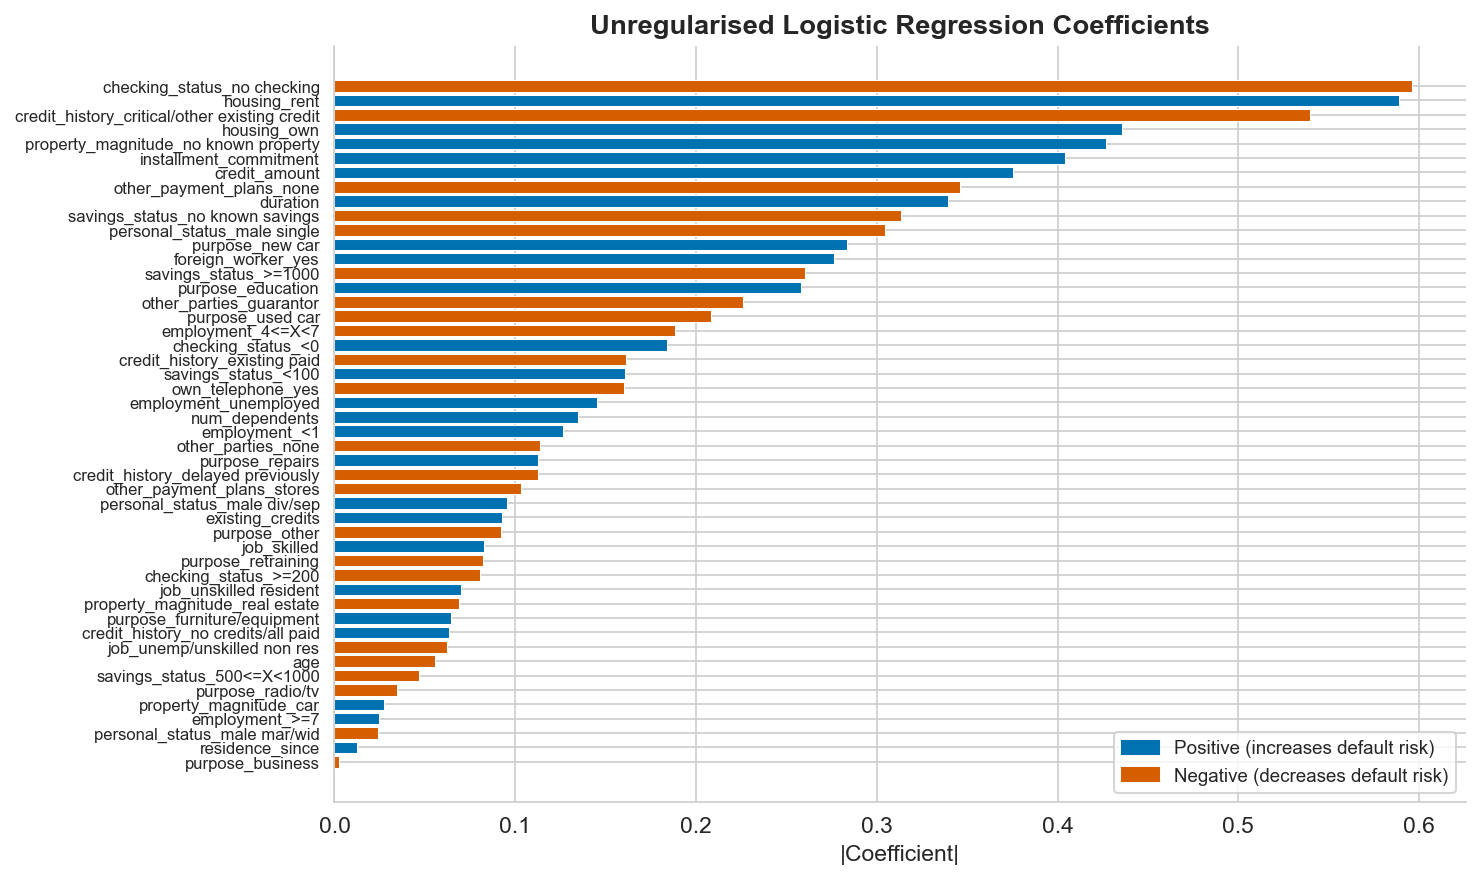

Number of non-zero coefficients: 48/48


In [4]:
# Fit unregularised logistic regression as baseline
lr_none = LogisticRegression(penalty=None, max_iter=5000, random_state=SEED)
lr_none.fit(X_train, y_train)
acc_none = accuracy_score(y_test, lr_none.predict(X_test))
print(f"Unregularised accuracy: {acc_none:.4f}")

# Plot coefficient magnitudes
coefs_none = lr_none.coef_[0]
sort_idx = np.argsort(np.abs(coefs_none))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colours = [CB_COLOURS[0] if c > 0 else CB_COLOURS[1] for c in coefs_none[sort_idx]]
ax.barh(np.arange(len(feature_names)), np.abs(coefs_none[sort_idx]),
        color=colours, edgecolor='white', linewidth=0.5)
ax.set_yticks(np.arange(len(feature_names)))
ax.set_yticklabels(feature_names[sort_idx], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('|Coefficient|')
ax.set_title('Unregularised Logistic Regression Coefficients', fontweight='bold')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Legend for sign
from matplotlib.patches import Patch
ax.legend([Patch(color=CB_COLOURS[0]), Patch(color=CB_COLOURS[1])],
          ['Positive (increases default risk)', 'Negative (decreases default risk)'],
          loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/unregularised_coefficients.png', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Number of non-zero coefficients: {np.sum(coefs_none != 0)}/{len(coefs_none)}")

## 3. L1 and L2: Two Approaches to Shrinking Coefficients

Both L1 and L2 add a penalty term to the logistic regression loss function:

- **L2 (Ridge):** Minimise `Loss + (1/C) * Σ βᵢ²` — penalises the *sum of squared* coefficients
- **L1 (Lasso):** Minimise `Loss + (1/C) * Σ |βᵢ|` — penalises the *sum of absolute* coefficients

Here, `C` is the **inverse regularisation strength** in scikit-learn: smaller C = stronger penalty.

**The geometric intuition:** Think of the penalty as a constraint region. L2's constraint is a *circle* (in 2D), so the optimal solution slides along the circle's surface — coefficients shrink smoothly but never reach zero. L1's constraint is a *diamond*, which has **corners on the axes**. The optimal solution often lands at a corner, meaning one or more coefficients become exactly zero. This is why L1 performs **automatic feature selection**.

Let's watch this happen in practice.

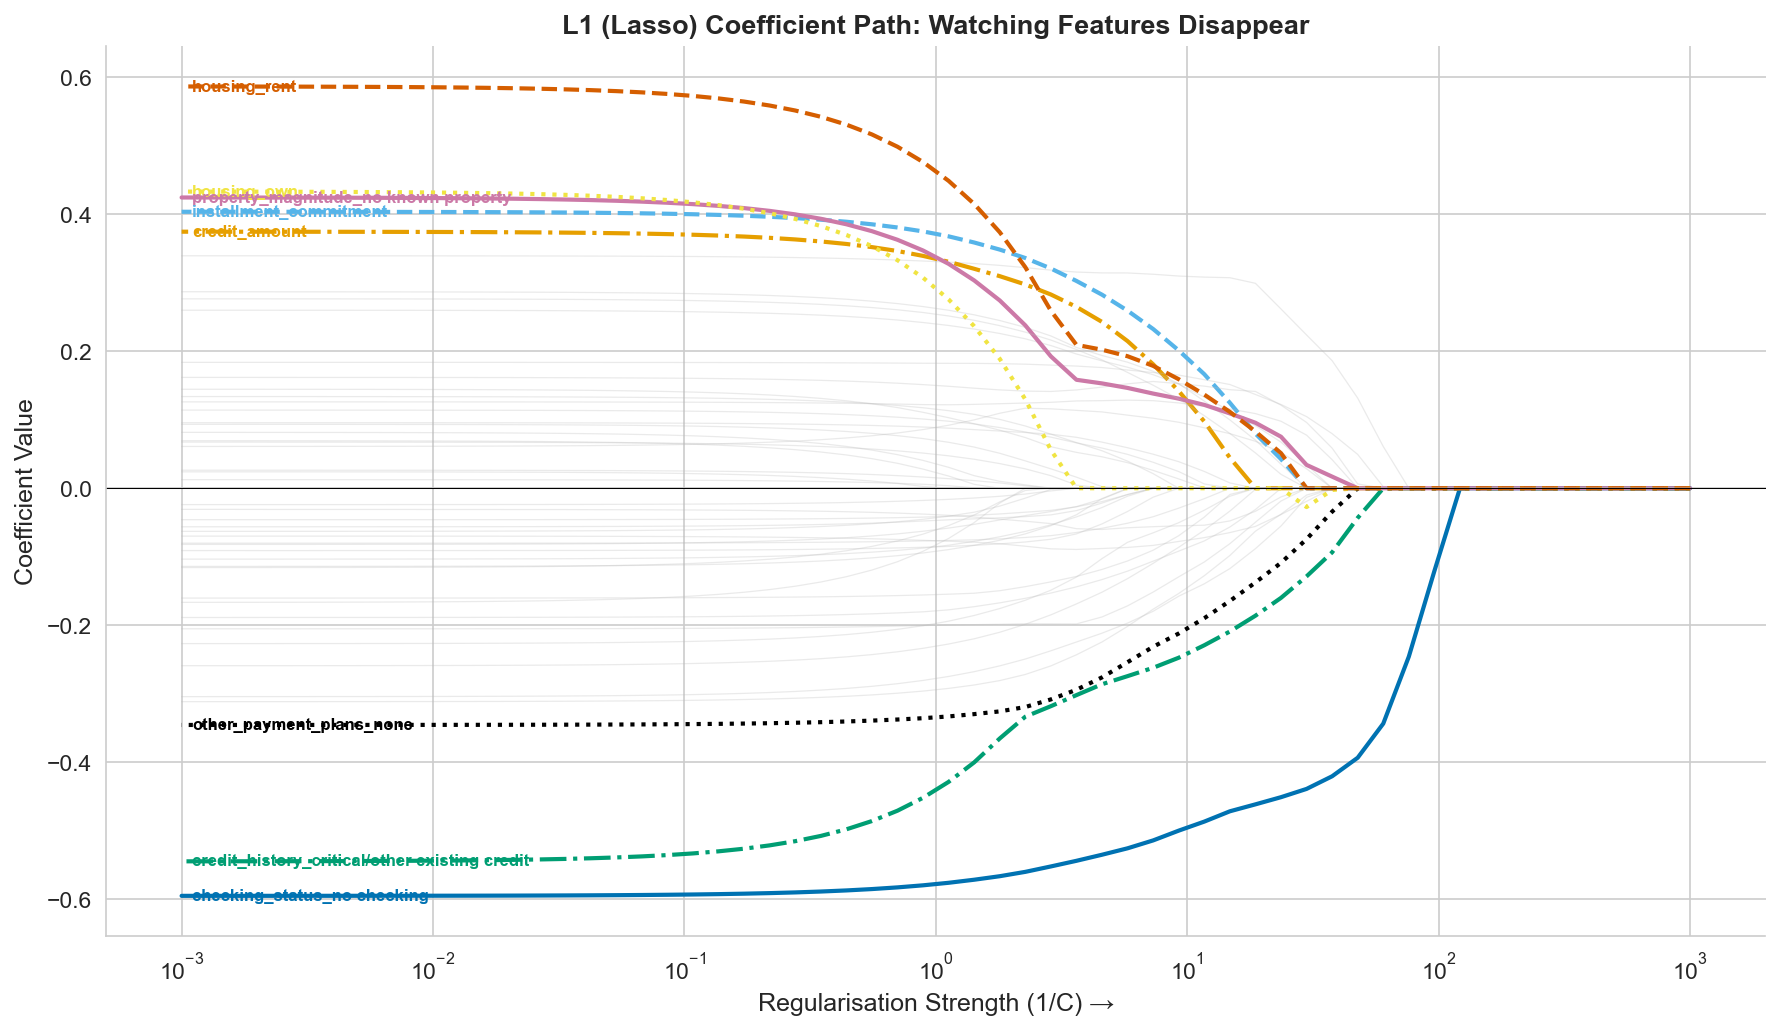

Features surviving at weakest penalty (C=1000): 48
Features surviving at strongest penalty (C=0.001): 0


In [5]:
# L1 Coefficient Path — sweep regularisation strength
C_values = np.logspace(-3, 3, 60)  # From very strong to very weak penalty
l1_coefs = []

for C in C_values:
    lr = LogisticRegression(penalty='l1', C=C, solver='saga', max_iter=5000, random_state=SEED)
    lr.fit(X_train, y_train)
    l1_coefs.append(lr.coef_[0].copy())

l1_coefs = np.array(l1_coefs)  # shape: (60, n_features)

# Plot L1 coefficient paths
fig, ax = plt.subplots(figsize=(12, 7))
reg_strength = 1.0 / C_values  # Convert to regularisation strength (higher = more penalty)

# Find top 8 features by max absolute coefficient to label them
max_abs_coef = np.max(np.abs(l1_coefs), axis=0)
top_indices = np.argsort(max_abs_coef)[::-1][:8]

for j in range(l1_coefs.shape[1]):
    lw = 2.0 if j in top_indices else 0.6
    alpha = 1.0 if j in top_indices else 0.3
    idx = np.where(top_indices == j)[0]
    colour = CB_COLOURS[idx[0] % len(CB_COLOURS)] if len(idx) > 0 else '#BBBBBB'
    ls = LINE_STYLES[idx[0] % len(LINE_STYLES)] if len(idx) > 0 else '-'
    ax.plot(reg_strength, l1_coefs[:, j], color=colour, linewidth=lw, alpha=alpha, linestyle=ls)

# Add labels at right edge for top features
for rank, j in enumerate(top_indices):
    y_val = l1_coefs[-1, j]
    ax.annotate(feature_names[j], xy=(reg_strength[-1], y_val),
                fontsize=8, fontweight='bold', color=CB_COLOURS[rank % len(CB_COLOURS)],
                xytext=(5, 0), textcoords='offset points', va='center')

ax.set_xscale('log')
ax.set_xlabel('Regularisation Strength (1/C) →', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('L1 (Lasso) Coefficient Path: Watching Features Disappear', fontweight='bold', fontsize=13)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/l1_coefficient_path.png', bbox_inches='tight', facecolor='white')
plt.show()

# Count surviving features at each C
n_surviving = np.sum(np.abs(l1_coefs) > 1e-10, axis=1)
print(f"Features surviving at weakest penalty (C={C_values[-1]:.0f}): {n_surviving[-1]}")
print(f"Features surviving at strongest penalty (C={C_values[0]:.3f}): {n_surviving[0]}")

## 4. The L1 Path: Watching Features Disappear

Read the coefficient path plot from **right to left** (weak penalty → strong penalty):

1. **Right side (weak penalty):** Almost all features have non-zero coefficients — the model behaves like unregularised logistic regression
2. **Middle:** As penalty increases, less important features' coefficients hit **exactly zero** and flatline. This is L1's signature behaviour — it doesn't just shrink, it **eliminates**
3. **Left side (strong penalty):** Only the most important features survive. These are the features with the strongest predictive signal

**The features that survive the longest are the most robustly important.** This gives us a natural ranking of feature importance that's directly tied to the model's regularisation behaviour — not a post-hoc importance measure.

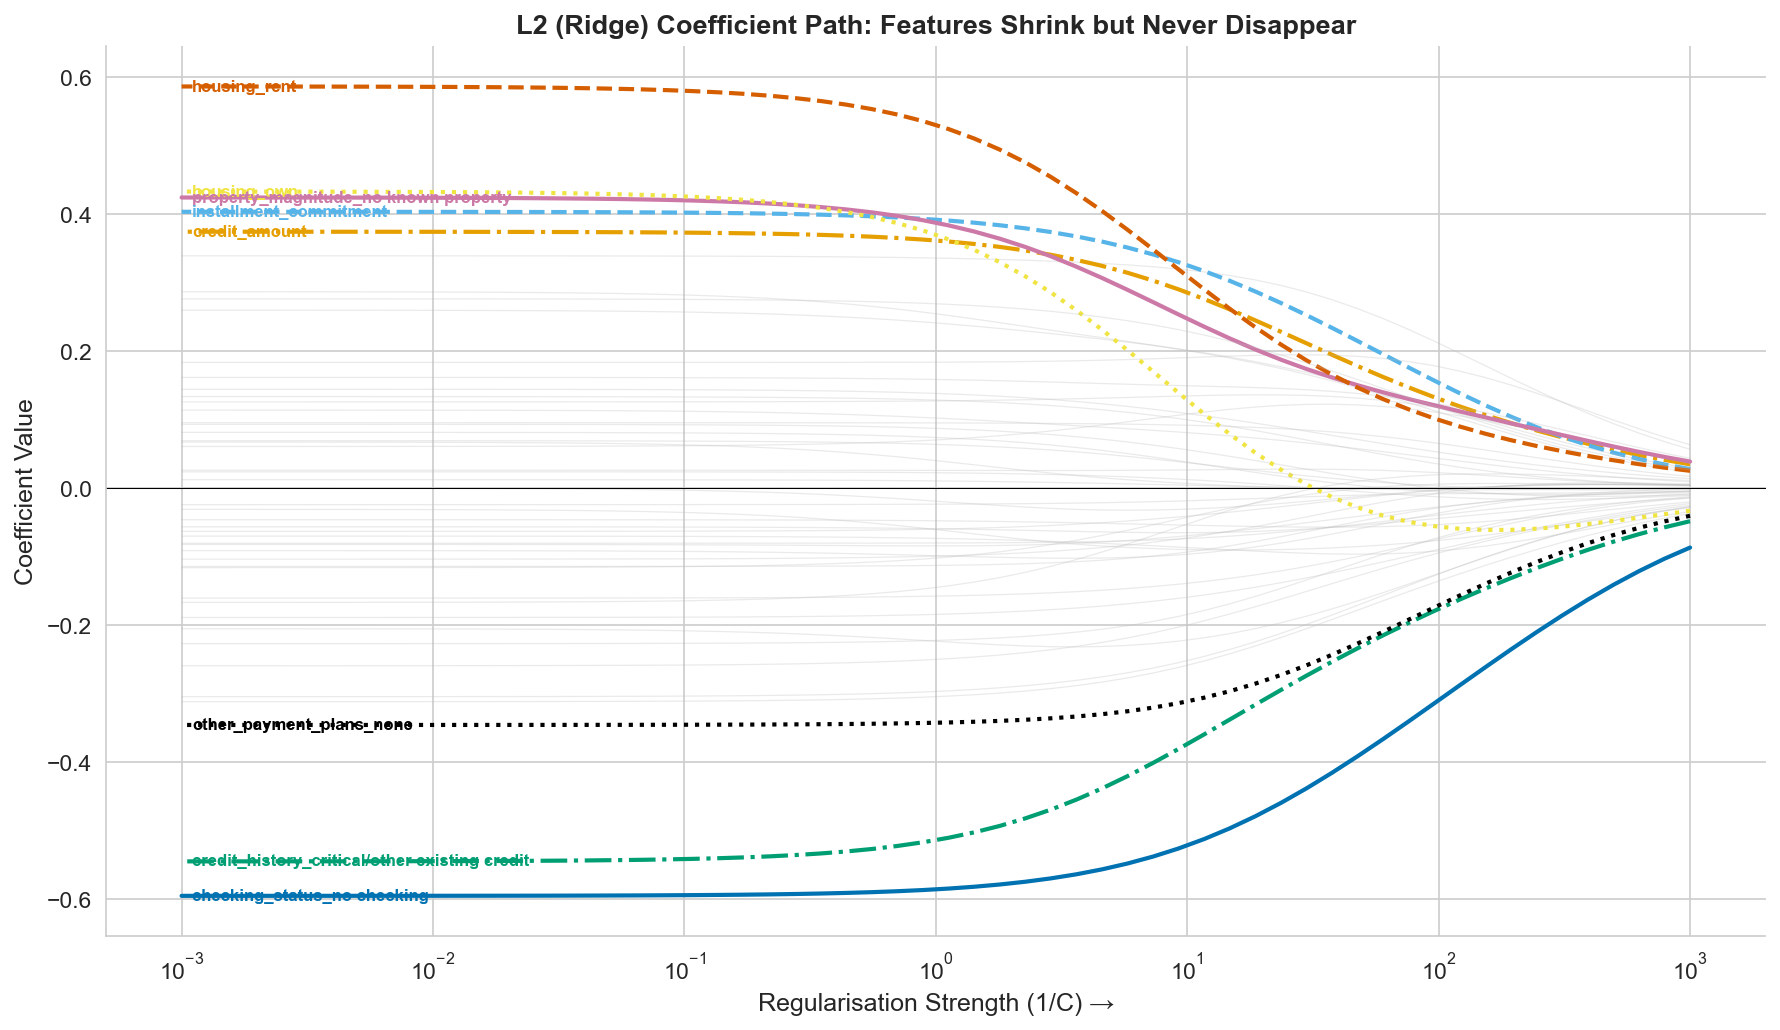

L2 features surviving at strongest penalty: 48 (compare L1: 0)
Key insight: L2 NEVER eliminates features — they all approach zero but never reach it.


In [6]:
# L2 Coefficient Path — same sweep with L2 penalty
l2_coefs = []

for C in C_values:
    lr = LogisticRegression(penalty='l2', C=C, solver='saga', max_iter=5000, random_state=SEED)
    lr.fit(X_train, y_train)
    l2_coefs.append(lr.coef_[0].copy())

l2_coefs = np.array(l2_coefs)

# Plot L2 coefficient paths
fig, ax = plt.subplots(figsize=(12, 7))

for j in range(l2_coefs.shape[1]):
    lw = 2.0 if j in top_indices else 0.6
    alpha = 1.0 if j in top_indices else 0.3
    idx = np.where(top_indices == j)[0]
    colour = CB_COLOURS[idx[0] % len(CB_COLOURS)] if len(idx) > 0 else '#BBBBBB'
    ls = LINE_STYLES[idx[0] % len(LINE_STYLES)] if len(idx) > 0 else '-'
    ax.plot(reg_strength, l2_coefs[:, j], color=colour, linewidth=lw, alpha=alpha, linestyle=ls)

for rank, j in enumerate(top_indices):
    y_val = l2_coefs[-1, j]
    ax.annotate(feature_names[j], xy=(reg_strength[-1], y_val),
                fontsize=8, fontweight='bold', color=CB_COLOURS[rank % len(CB_COLOURS)],
                xytext=(5, 0), textcoords='offset points', va='center')

ax.set_xscale('log')
ax.set_xlabel('Regularisation Strength (1/C) →', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('L2 (Ridge) Coefficient Path: Features Shrink but Never Disappear', fontweight='bold', fontsize=13)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/l2_coefficient_path.png', bbox_inches='tight', facecolor='white')
plt.show()

n_surviving_l2 = np.sum(np.abs(l2_coefs) > 1e-10, axis=1)
print(f"L2 features surviving at strongest penalty: {n_surviving_l2[0]} (compare L1: {n_surviving[0]})")
print("Key insight: L2 NEVER eliminates features — they all approach zero but never reach it.")

## 5. Why L2 Never Reaches Zero

Compare the two path plots side by side in your mind:

- **L1 path:** Coefficients hit zero and stay there. As penalty increases, features are *eliminated* one by one
- **L2 path:** All coefficients shrink toward zero but **never actually reach it**. Even at extreme penalties, every feature retains a tiny non-zero coefficient

**Why the difference?** It comes down to the gradient near zero:
- L2's penalty gradient is `2β`, which approaches zero as β approaches zero — the penalty "loses interest" in pushing further
- L1's penalty gradient is a constant `±1` regardless of β — it pushes with the same force all the way to zero and through it

This mathematical property makes L1 a **built-in feature selector**, while L2 is purely a **regulariser** that prevents overfitting without eliminating features.

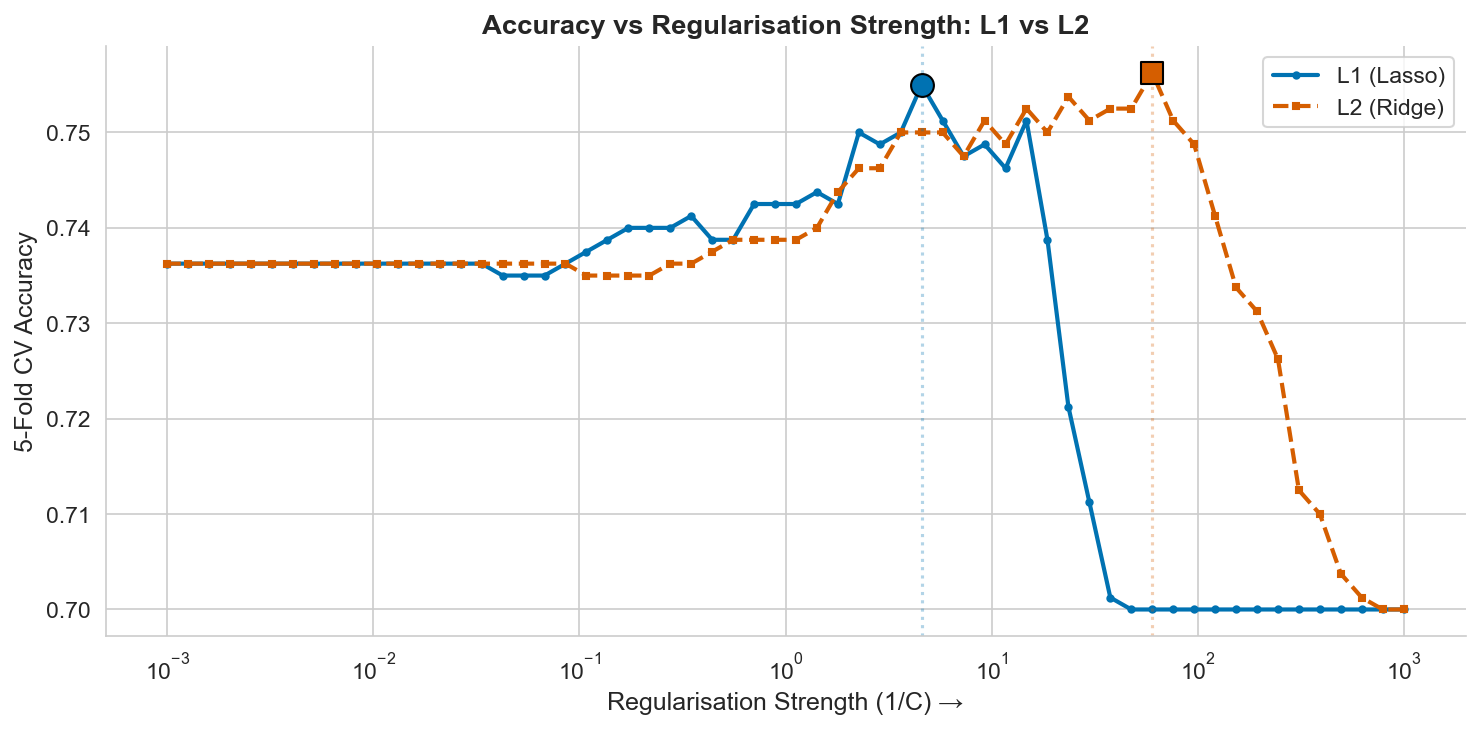

Best L1: C=0.218, accuracy=0.7550
Best L2: C=0.017, accuracy=0.7562


In [7]:
# Cross-validated accuracy vs regularisation strength
from sklearn.model_selection import StratifiedKFold

l1_accuracies = []
l2_accuracies = []

for C in C_values:
    # L1
    lr_l1 = LogisticRegression(penalty='l1', C=C, solver='saga', max_iter=5000, random_state=SEED)
    scores_l1 = cross_val_score(lr_l1, X_train, y_train, cv=5, scoring='accuracy')
    l1_accuracies.append(scores_l1.mean())
    
    # L2
    lr_l2 = LogisticRegression(penalty='l2', C=C, solver='saga', max_iter=5000, random_state=SEED)
    scores_l2 = cross_val_score(lr_l2, X_train, y_train, cv=5, scoring='accuracy')
    l2_accuracies.append(scores_l2.mean())

l1_accuracies = np.array(l1_accuracies)
l2_accuracies = np.array(l2_accuracies)

# Plot accuracy vs C
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(reg_strength, l1_accuracies, color=CB_COLOURS[0], linewidth=2, marker='o',
        markersize=3, label='L1 (Lasso)')
ax.plot(reg_strength, l2_accuracies, color=CB_COLOURS[1], linewidth=2, marker='s',
        markersize=3, linestyle='--', label='L2 (Ridge)')

# Mark best C for each
best_l1_idx = np.argmax(l1_accuracies)
best_l2_idx = np.argmax(l2_accuracies)
ax.axvline(reg_strength[best_l1_idx], color=CB_COLOURS[0], alpha=0.3, linestyle=':')
ax.axvline(reg_strength[best_l2_idx], color=CB_COLOURS[1], alpha=0.3, linestyle=':')
ax.scatter([reg_strength[best_l1_idx]], [l1_accuracies[best_l1_idx]],
           color=CB_COLOURS[0], s=120, zorder=5, edgecolors='black')
ax.scatter([reg_strength[best_l2_idx]], [l2_accuracies[best_l2_idx]],
           color=CB_COLOURS[1], s=120, zorder=5, edgecolors='black', marker='s')

ax.set_xscale('log')
ax.set_xlabel('Regularisation Strength (1/C) →', fontsize=12)
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)
ax.set_title('Accuracy vs Regularisation Strength: L1 vs L2', fontweight='bold')
ax.legend(fontsize=11)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/accuracy_vs_regularisation.png', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Best L1: C={C_values[best_l1_idx]:.3f}, accuracy={l1_accuracies[best_l1_idx]:.4f}")
print(f"Best L2: C={C_values[best_l2_idx]:.3f}, accuracy={l2_accuracies[best_l2_idx]:.4f}")

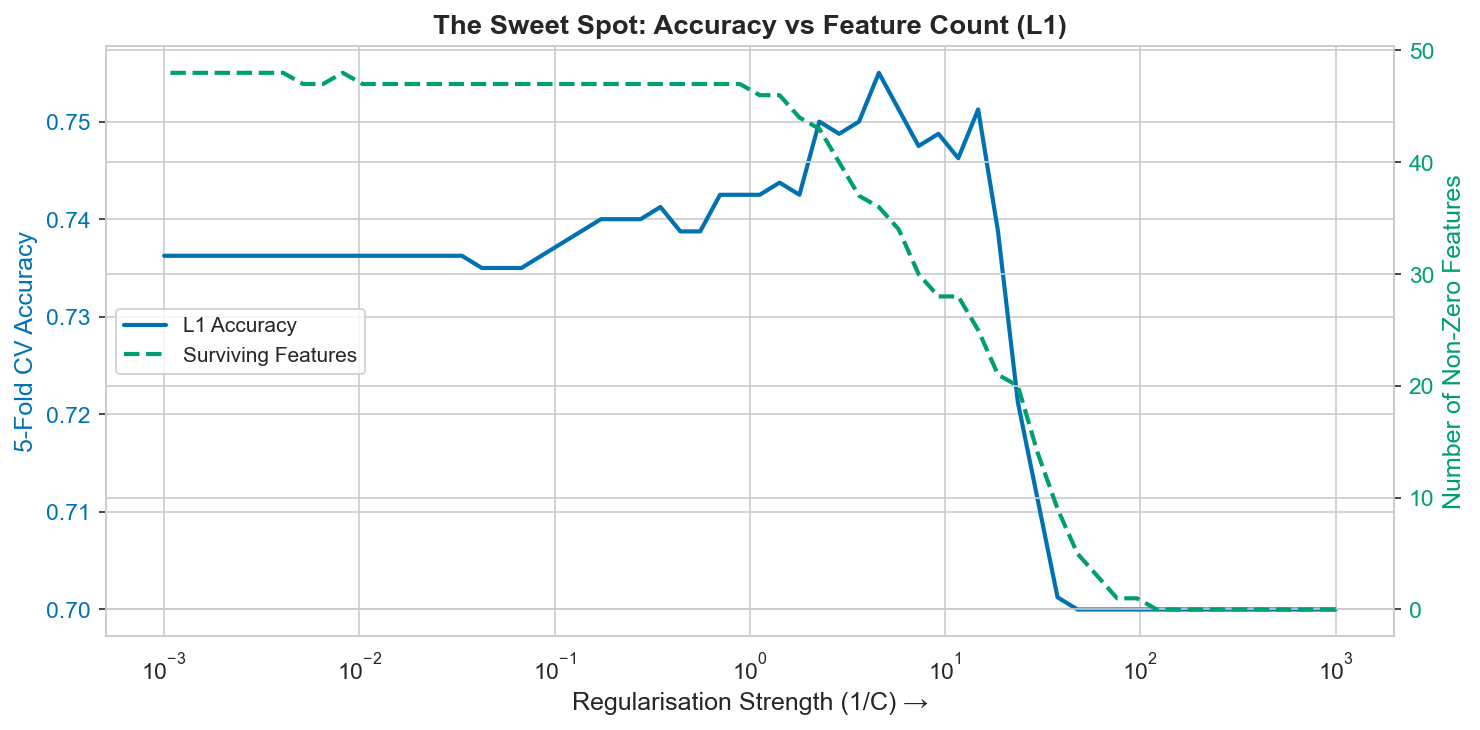

At optimal L1 penalty (C=0.218):
  Accuracy: 0.7550
  Surviving features: 36 out of 48
  Features eliminated: 12


In [8]:
# Number of surviving L1 features vs accuracy
fig, ax1 = plt.subplots(figsize=(10, 5))

colour_acc = CB_COLOURS[0]
colour_feat = CB_COLOURS[2]

ax1.plot(reg_strength, l1_accuracies, color=colour_acc, linewidth=2, label='L1 Accuracy')
ax1.set_xlabel('Regularisation Strength (1/C) →', fontsize=12)
ax1.set_ylabel('5-Fold CV Accuracy', color=colour_acc, fontsize=12)
ax1.tick_params(axis='y', labelcolor=colour_acc)
ax1.set_xscale('log')

ax2 = ax1.twinx()
ax2.plot(reg_strength, n_surviving, color=colour_feat, linewidth=2, linestyle='--',
         label='Surviving Features')
ax2.set_ylabel('Number of Non-Zero Features', color=colour_feat, fontsize=12)
ax2.tick_params(axis='y', labelcolor=colour_feat)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=10)

ax1.set_title('The Sweet Spot: Accuracy vs Feature Count (L1)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/features_vs_accuracy.png', bbox_inches='tight', facecolor='white')
plt.show()

# Find the sweet spot
best_c_idx = best_l1_idx
print(f"At optimal L1 penalty (C={C_values[best_c_idx]:.3f}):")
print(f"  Accuracy: {l1_accuracies[best_c_idx]:.4f}")
print(f"  Surviving features: {n_surviving[best_c_idx]} out of {len(feature_names)}")
print(f"  Features eliminated: {len(feature_names) - n_surviving[best_c_idx]}")

## 6. Finding the Right Penalty Strength

The dual-axis plot above reveals a crucial insight: **accuracy does not require all features.** As we increase L1 penalty from the right side, features get eliminated, yet accuracy remains stable or even improves (due to reduced overfitting). There exists a "sweet spot" where:

- Enough features survive to capture the important patterns
- Noisy or redundant features have been eliminated
- The model generalises well without memorising training noise

This is the practical power of L1 regularisation: it simultaneously regularises the model and performs feature selection, giving you a simpler, more interpretable model without sacrificing (and sometimes improving) performance.

## 7. When to Use L1 vs L2

| Situation | Use L1 (Lasso) | Use L2 (Ridge) |
|-----------|----------------|----------------|
| You want automatic feature selection | ✓ | ✗ |
| You have many irrelevant features | ✓ | ✗ |
| Features are highly correlated | ✗ (selects one arbitrarily) | ✓ (keeps all, shrinks evenly) |
| You need all features in the final model | ✗ | ✓ |
| Interpretability is a priority | ✓ (sparse model) | Partial (all features present) |
| You want stable coefficient estimates | ✗ (can be unstable with correlated features) | ✓ |

**Rule of thumb:** Start with L1 to see which features survive. If you suspect correlated feature groups, switch to L2 or consider Elastic Net (a blend of both).

## 8. Limitations

- **Single model:** We only tested logistic regression; regularisation behaves differently in tree-based or deep learning models
- **Single dataset:** Results are specific to this credit dataset; other domains may show different patterns
- **Label encoding choices:** The way we encoded categoricals affects which features get eliminated
- **SAGA solver:** Convergence warnings may occur at extreme C values, affecting coefficient precision

## 9. Ethical Considerations

Credit scoring models have direct, material impact on people's lives — they determine who gets loans, at what interest rate, and who gets denied. This raises critical ethical concerns:

- **Fairness:** If features like gender, age, or marital status survive L1 regularisation, the model may encode discriminatory patterns from historical data
- **Transparency:** Regularisation makes models simpler and more interpretable, which supports the "right to explanation" required by regulations like the EU's GDPR
- **Impact of false positives:** Predicting someone will default when they won't can deny them credit unfairly, with cascading effects on their financial wellbeing
- **Feature proxy effects:** Even if protected attributes are removed, other features (like zip code) may serve as proxies for race or socioeconomic status

## Accessibility Statement

- **Colour-blind friendly:** All plots use the Okabe-Ito palette with distinct line styles (solid, dashed, dot-dash) so features are distinguishable without colour
- **Feature labels:** Key features are labelled directly on coefficient path plots
- **High contrast:** White backgrounds, dark text, visible grid lines
- **Text summaries:** Key numerical results are printed alongside every visualisation
- **Line weight variation:** Important features use thick lines (2pt) while background features use thin lines (0.6pt)

## References

1. Tibshirani, R. (1996). Regression Shrinkage and Selection via the Lasso. *JRSS-B*, 58(1), 267-288.
2. Hoerl, A. E. & Kennard, R. W. (1970). Ridge Regression. *Technometrics*, 12(1), 55-67.
3. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. 2nd Ed. Springer.
4. Yeh, I.-C. & Lien, C.-H. (2009). Credit card default prediction. *Expert Systems with Applications*, 36(2).
5. Scikit-learn documentation: [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)